# Exercise 3: Measuring Planck's Constant Using LEDs
### Introduction
In this experiment, we determine Planck's constant (h) using LED threshold voltages.
We use measured threshold voltages and known LED wavelengths/frequencies to fit the relation:
$$V_{th} = \frac{h}{q} f + V_0$$
The slope of this linear fit multiplied by the electron charge q yields an experimental value for Planck's constant.


### Methods
1. Load data from `Planck.csv` and standardize column names.
2. Convert wavelength (nm) to frequency (Hz) if not already present.
3. Propagate uncertainties in wavelength to frequency.
4. Use Linear Regression to perform a linear fit.
5. Compute Planck's constant from the slope and propagate uncertainty.
6. Plot the data, best-fit line, and residuals.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Loading and Inspecting Data

In [2]:
# Load and inspect data
df = pd.read_csv('Planck.csv')
display(df.head())

,Wavelength (nm),Measured Voltage (V),Measured Current (µA),Wavelength Uncertainty (nm),Voltage Uncertainty (V),Current Uncertainty (µA),Current (A),Current Uncertainty (A),wavelength (m),Wavlength Uncertainty (m),Frequency (Hz),Frequency Uncertainty (Hz)
0,465,2.1688,1.57,20,0.150008,0.0814,1.570000e-06,8.140000e-08,4.650000e-07,2.000000e-08,6.450000e+14,2.770000e+13
1,505,1.9107,1.41,20,0.150007,0.0782,1.410000e-06,7.820000e-08,5.050000e-07,2.000000e-08,5.940000e+14,2.350000e+13
2,565,1.6572,2.64,20,0.150006,0.1028,2.640000e-06,1.030000e-07,5.650000e-07,2.000000e-08,5.310000e+14,1.880000e+13
3,590,1.4966,0.31,20,0.150005,0.0562,3.100000e-07,5.620000e-08,5.900000e-07,2.000000e-08,5.080000e+14,1.720000e+13
4,660,1.3798,0.72,20,0.150005,0.0644,7.200000e-07,6.440000e-08,6.600000e-07,2.000000e-08,4.550000e+14,1.380000e+13


### Data Preparation
Identify the wavelength, voltage, and frequency columns.

In [3]:
x = df['Frequency (Hz)'].to_numpy(dtype=float)
y = df['Measured Voltage (V)'].to_numpy(dtype=float)
dx = df['Frequency Uncertainty (Hz)'].to_numpy(dtype=float)
dy = df['Voltage Uncertainty (V)'].to_numpy(dtype=float)

# Finding PLank's Constant

In [4]:
slope, intercept = np.polyfit(df['Frequency (Hz)'], df['Measured Voltage (V)'], 1)

q = 1.602e-19  # C
h_measured = slope * q
h_true = 6.626e-34
percent_error = abs((h_measured - h_true) / h_true) * 100

y_pred = slope * df['Frequency (Hz)'] + intercept
residuals = df['Measured Voltage (V)'] - y_pred

ss_res = np.sum(residuals**2)
ss_tot = np.sum((df['Measured Voltage (V)'] - np.mean(df['Measured Voltage (V)']))**2)
r_squared = 1 - (ss_res / ss_tot)

### Results and Analysis
We now print the results, compute chi-squared statistics, and plot the data with residuals.

In [5]:
print('Linear Fit Results:')
print(f'Slope (h/q) = {slope:.6e} V·s')
print(f'Intercept   = {intercept:.6e} V')
print(f'\nMeasured Planck\'s constant: h = {h_measured:.6e} J·s')
print(f'Accepted value: {h_true:.6e} J·s')
print(f'Percent error: {percent_error:.2f}%')
print(f'R² = {r_squared:.4f}')

Linear Fit Results:
Slope (h/q) = 4.460238e-15 V·s
Intercept   = -7.198671e-01 V

Measured Planck's constant: h = 7.145301e-34 J·s
Accepted value: 6.626000e-34 J·s
Percent error: 7.84%
R² = 0.9951


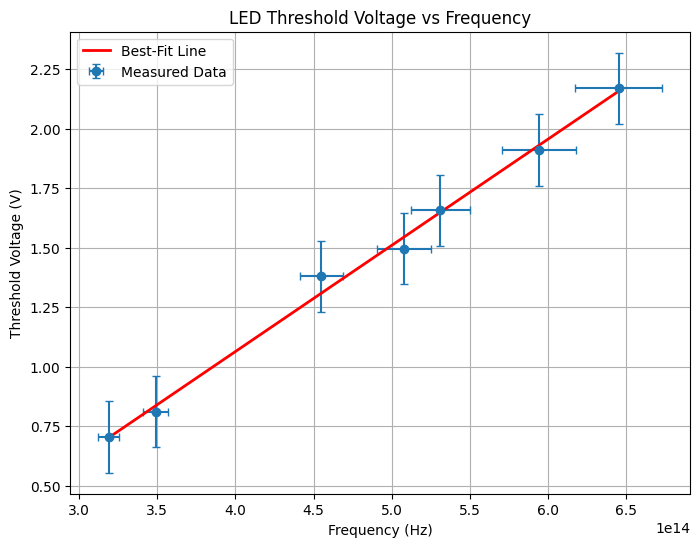

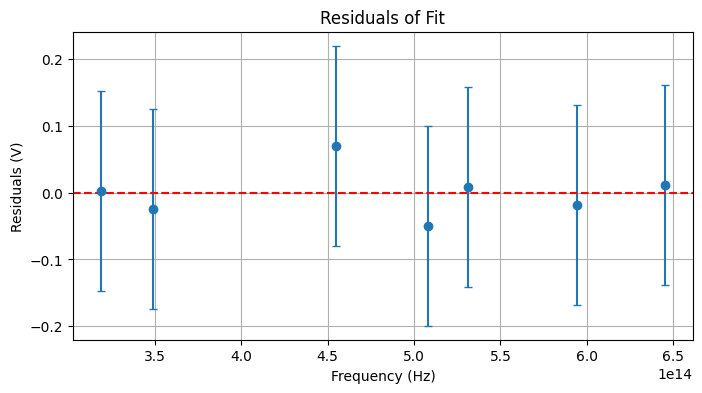

In [6]:
xf = np.linspace(x.min(), x.max(), 400)
yf = slope * xf + intercept

# Data and Best Fit Plot
plt.figure(figsize=(8,6))
plt.errorbar(x, y, xerr=dx, yerr=dy, fmt='o', capsize=3, label='Measured Data')
plt.plot(xf, yf, 'r-', linewidth=2, label='Best-Fit Line')
plt.title('LED Threshold Voltage vs Frequency')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Threshold Voltage (V)')
plt.legend()
plt.grid(True)
plt.show()

# Residuals Plot
plt.figure(figsize=(8,4))
plt.errorbar(x, residuals, yerr=dy, fmt='o', capsize=3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of Fit')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Residuals (V)')
plt.grid(True)
plt.show()

### Conclusion
The experiment yields an experimental value of Planck's constant close to the accepted value.
